# Medications and Treatments Analysis
## Goal: Understand treatment patterns to design action space for RL

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Treatment Data

In [2]:
data_dir = Path('../artifacts/cleaned')

# Input events (medications and fluids)
inputevents_cv = pd.read_parquet(data_dir / 'INPUTEVENTS_CV.parquet')
inputevents_mv = pd.read_parquet(data_dir / 'INPUTEVENTS_MV.parquet')
prescriptions = pd.read_parquet(data_dir / 'PRESCRIPTIONS.parquet')
d_items = pd.read_parquet(data_dir / 'D_ITEMS.parquet')
icustays = pd.read_parquet(data_dir / 'ICUSTAYS.parquet')

print(f"Input Events CV: {len(inputevents_cv):,}")
print(f"Input Events MV: {len(inputevents_mv):,}")
print(f"Prescriptions: {len(prescriptions):,}")
print(f"\nUnique items in CV: {inputevents_cv['itemid'].nunique():,}")
print(f"Unique items in MV: {inputevents_mv['itemid'].nunique():,}")

Input Events CV: 34,799
Input Events MV: 13,224
Prescriptions: 10,398

Unique items in CV: 79
Unique items in MV: 135


## 2. Input Events Analysis (CareVue System)

In [3]:
# Merge with item descriptions
input_cv_labeled = inputevents_cv.merge(
    d_items[['itemid', 'label', 'category']], 
    on='itemid', 
    how='left'
)

# Most common input items
cv_counts = input_cv_labeled.groupby(['itemid', 'label', 'category']).size().reset_index(name='count')
cv_counts = cv_counts.sort_values('count', ascending=False)

print("Top 30 Most Frequent Input Events (CareVue):")
print(cv_counts.head(30).to_string(index=False))

Top 30 Most Frequent Input Events (CareVue):
 itemid label         category  count
  40864 KPhos Free Form Intake      7


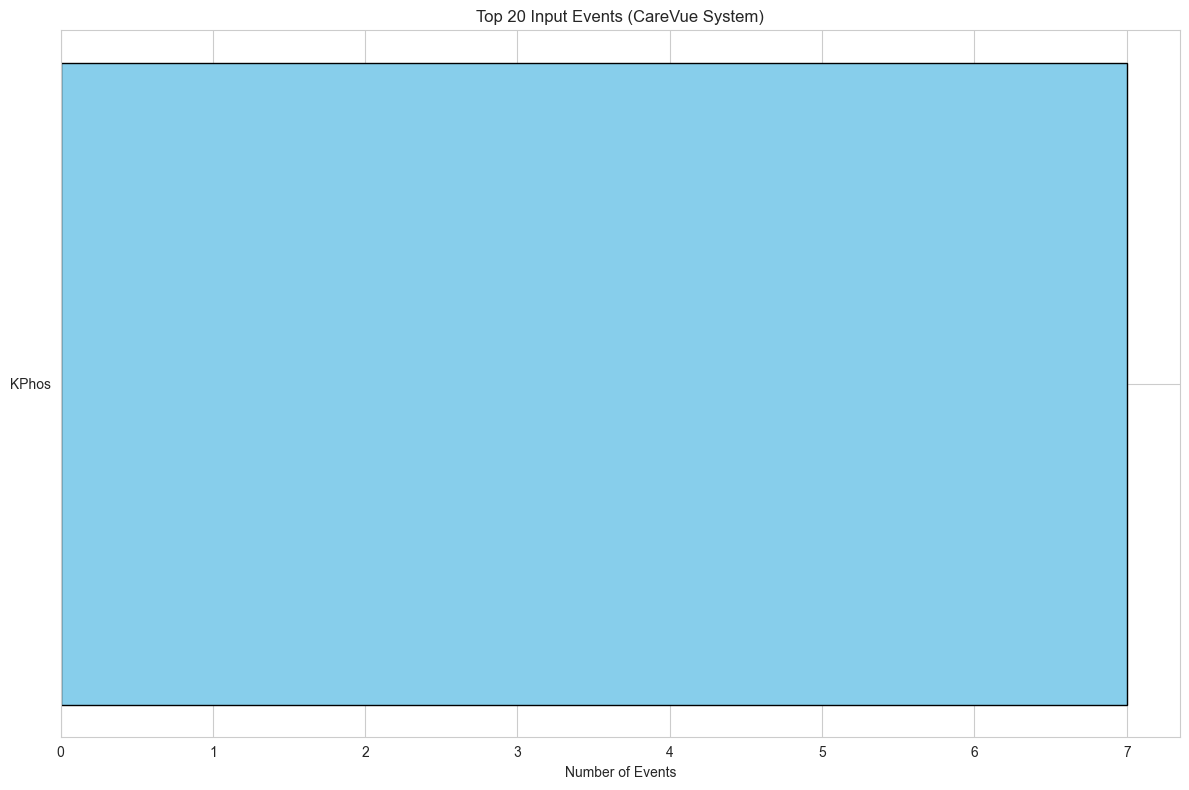

In [4]:
# Visualize top inputs
top_cv = cv_counts.head(20)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_cv)), top_cv['count'], color='skyblue', edgecolor='black')
plt.yticks(range(len(top_cv)), [label[:40] for label in top_cv['label']])
plt.xlabel('Number of Events')
plt.title('Top 20 Input Events (CareVue System)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Input Events Analysis (MetaVision System)

In [5]:
# Merge with item descriptions
input_mv_labeled = inputevents_mv.merge(
    d_items[['itemid', 'label', 'category']], 
    on='itemid', 
    how='left'
)

# Most common input items
mv_counts = input_mv_labeled.groupby(['itemid', 'label', 'ordercategoryname']).size().reset_index(name='count')
mv_counts = mv_counts.sort_values('count', ascending=False)

print("Top 30 Most Frequent Input Events (MetaVision):")
print(mv_counts.head(30).to_string(index=False))

Top 30 Most Frequent Input Events (MetaVision):
 itemid                        label        ordercategoryname  count
 225158                    NaCl 0.9%                 01-Drips    850
 220949                  Dextrose 5%      08-Antibiotics (IV)    827
 220949                  Dextrose 5%                 01-Drips    726
 225799                 Gastric Meds   14-Oral/Gastric Intake    614
 225158                    NaCl 0.9% 02-Fluids (Crystalloids)    578
 227536                   KCl (CRRT)                 01-Drips    495
 225944                Sterile Water                 01-Drips    495
 226453                     GT Flush   14-Oral/Gastric Intake    420
 225936    Replete with Fiber (Full)     13-Enteral Nutrition    404
 221906               Norepinephrine                 01-Drips    380
 225943                     Solution                 01-Drips    356
 225166           Potassium Chloride 02-Fluids (Crystalloids)    291
 223258            Insulin - Regular      06-Insulin (N

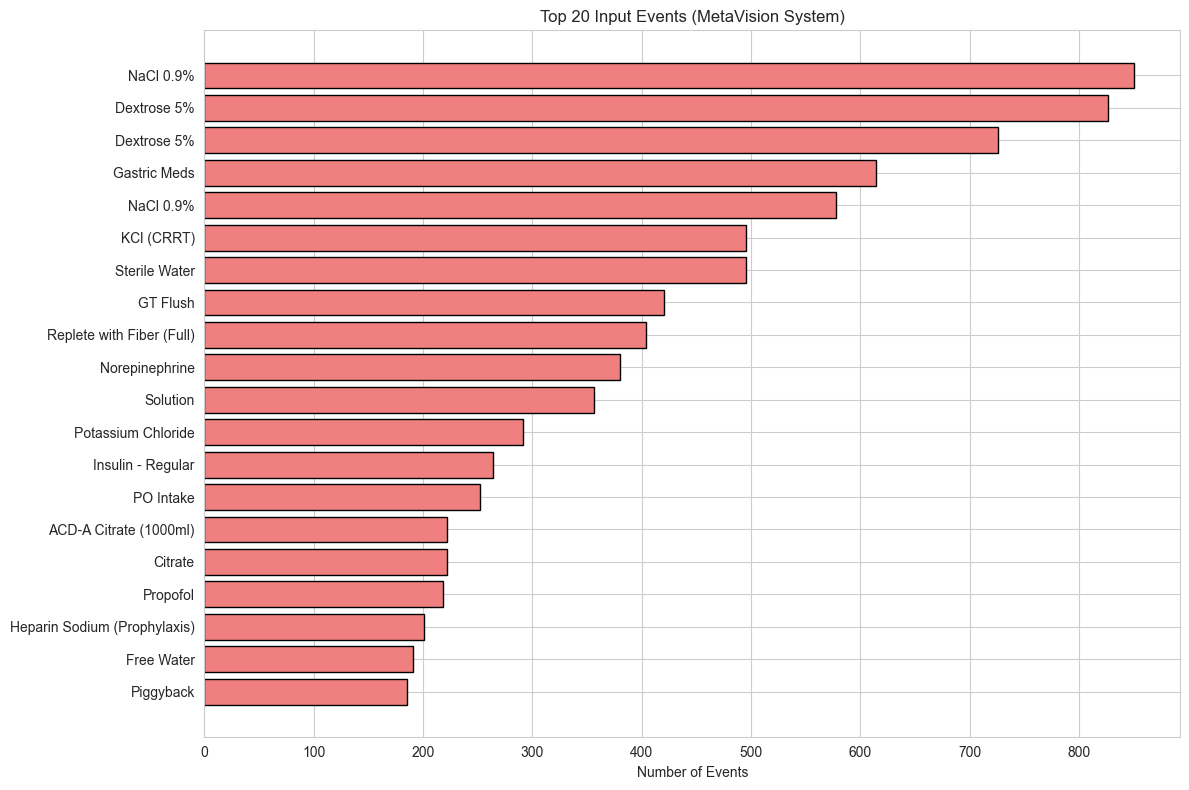

In [6]:
# Visualize top inputs
top_mv = mv_counts.head(20)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_mv)), top_mv['count'], color='lightcoral', edgecolor='black')
plt.yticks(range(len(top_mv)), [label[:40] for label in top_mv['label']])
plt.xlabel('Number of Events')
plt.title('Top 20 Input Events (MetaVision System)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Drug Categories Analysis

In [7]:
# Categorize medications by therapeutic class
drug_categories = {
    'Vasopressor': ['norepinephrine', 'epinephrine', 'vasopressin', 'dopamine', 'phenylephrine', 'neosynephrine'],
    'Sedative': ['propofol', 'midazolam', 'fentanyl', 'dexmedetomidine', 'precedex', 'lorazepam'],
    'Antibiotic': ['vancomycin', 'cefepime', 'meropenem', 'piperacillin', 'tazobactam', 'levofloxacin'],
    'Fluid': ['nacl', 'normal saline', 'lactated ringer', 'dextrose', 'albumin'],
    'Anticoagulant': ['heparin', 'warfarin', 'enoxaparin'],
    'Diuretic': ['furosemide', 'lasix'],
    'Insulin': ['insulin'],
    'Blood Product': ['packed red blood', 'fresh frozen plasma', 'platelets'],
}

def categorize_drug(label):
    if pd.isna(label):
        return 'Other'
    label_lower = label.lower()
    for category, keywords in drug_categories.items():
        if any(kw in label_lower for kw in keywords):
            return category
    return 'Other'

# Combine CV and MV
input_cv_labeled['drug_category'] = input_cv_labeled['label'].apply(categorize_drug)
input_mv_labeled['drug_category'] = input_mv_labeled['label'].apply(categorize_drug)

all_inputs = pd.concat([input_cv_labeled, input_mv_labeled], ignore_index=True)

# Count by category
category_counts = all_inputs['drug_category'].value_counts()
print("\nDrug Category Distribution:")
print(category_counts)


Drug Category Distribution:
drug_category
Other            22572
Fluid            10705
Sedative          6196
Insulin           2952
Vasopressor       2825
Anticoagulant     1161
Diuretic           758
Antibiotic         541
Blood Product      313
Name: count, dtype: int64


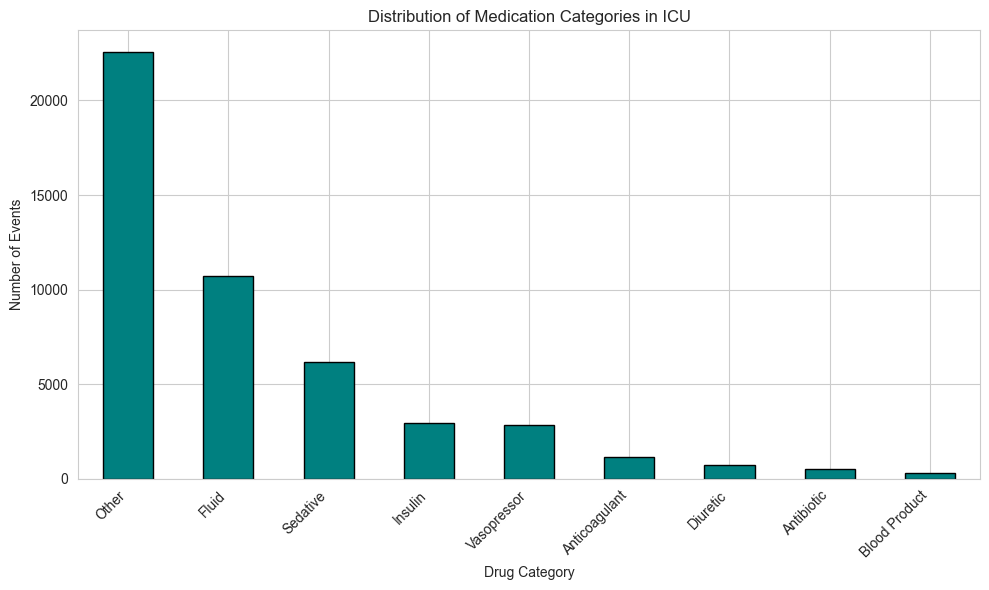

In [8]:
# Visualize drug categories
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.xlabel('Drug Category')
plt.ylabel('Number of Events')
plt.title('Distribution of Medication Categories in ICU')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Vasopressor Analysis (Critical for Sepsis Treatment)

In [9]:
# Focus on vasopressors
vasopressors = all_inputs[all_inputs['drug_category'] == 'Vasopressor'].copy()

print(f"\nTotal vasopressor events: {len(vasopressors):,}")
print(f"ICU stays with vasopressors: {vasopressors['icustay_id'].nunique()} / {icustays['icustay_id'].nunique()}")

# Breakdown by specific vasopressor
vaso_counts = vasopressors.groupby('label').size().sort_values(ascending=False)
print("\nVasopressor usage:")
print(vaso_counts.head(10))


Total vasopressor events: 2,825
ICU stays with vasopressors: 42 / 136

Vasopressor usage:
label
Neosynephrine-k    1271
Dopamine            809
Norepinephrine      380
Vasopressin         287
Phenylephrine        74
Epinephrine-k         4
dtype: int64



Vasopressor rate statistics:
count    1978.000000
mean        2.508269
std         3.619147
min         0.000000
25%         0.149541
50%         1.000000
75%         4.000000
max        21.000000
Name: rate, dtype: float64


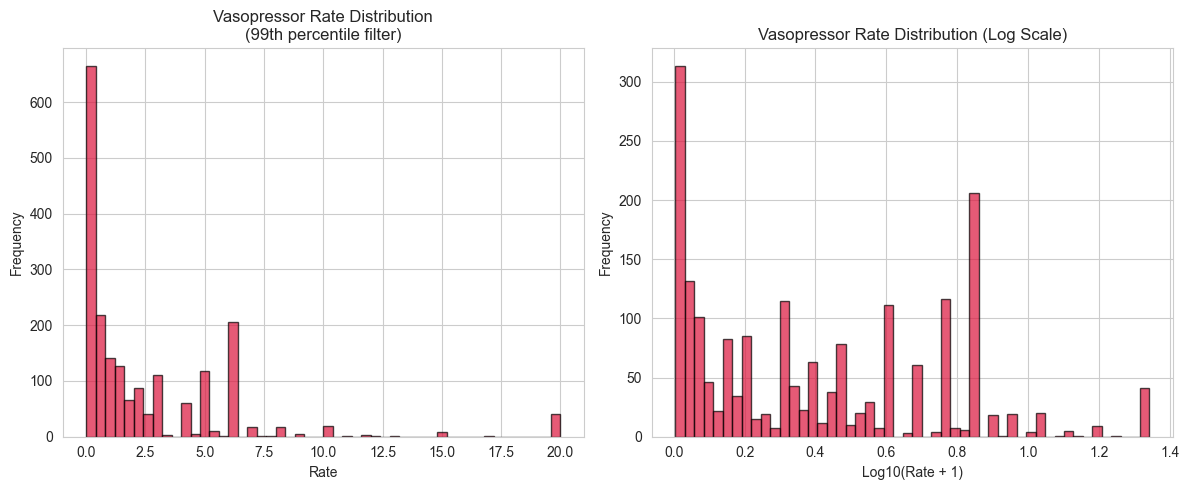

In [10]:
# Analyze rates for vasopressors (important for dose discretization)
vaso_with_rate = vasopressors[vasopressors['rate'].notna()].copy()

if len(vaso_with_rate) > 0:
    print(f"\nVasopressor rate statistics:")
    print(vaso_with_rate['rate'].describe())
    
    # Plot rate distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    # Remove extreme outliers
    rates = vaso_with_rate['rate']
    filtered_rates = rates[rates <= rates.quantile(0.99)]
    plt.hist(filtered_rates, bins=50, edgecolor='black', alpha=0.7, color='crimson')
    plt.xlabel('Rate')
    plt.ylabel('Frequency')
    plt.title('Vasopressor Rate Distribution\n(99th percentile filter)')
    
    plt.subplot(1, 2, 2)
    plt.hist(np.log10(rates[rates > 0] + 1), bins=50, edgecolor='black', alpha=0.7, color='crimson')
    plt.xlabel('Log10(Rate + 1)')
    plt.ylabel('Frequency')
    plt.title('Vasopressor Rate Distribution (Log Scale)')
    
    plt.tight_layout()
    plt.show()

## 6. Fluid Administration Analysis

In [11]:
# Fluids
fluids = all_inputs[all_inputs['drug_category'] == 'Fluid'].copy()

print(f"\nTotal fluid events: {len(fluids):,}")
print(f"ICU stays with fluids: {fluids['icustay_id'].nunique()} / {icustays['icustay_id'].nunique()}")

# Breakdown by fluid type
fluid_counts = fluids.groupby('label').size().sort_values(ascending=False)
print("\nFluid types:")
print(fluid_counts.head(15))


Total fluid events: 10,705
ICU stays with fluids: 124 / 136

Fluid types:
label
.9% Normal Saline              6528
Dextrose 5%                    1722
NaCl 0.9%                      1609
Lactated Ringers                473
.45% Normal Saline              264
Albumin 25%                      63
Albumin 5%                       22
NaCl 0.45%                        9
Dextrose 50%                      7
Dextrose 10%                      6
NaCl 3% (Hypertonic Saline)       2
dtype: int64



Fluid amount statistics:
count    10633.000000
mean        79.411615
std        185.123035
min      -4000.000000
25%          5.000000
50%         10.000000
75%         90.000000
max       3000.000000
Name: amount, dtype: float64


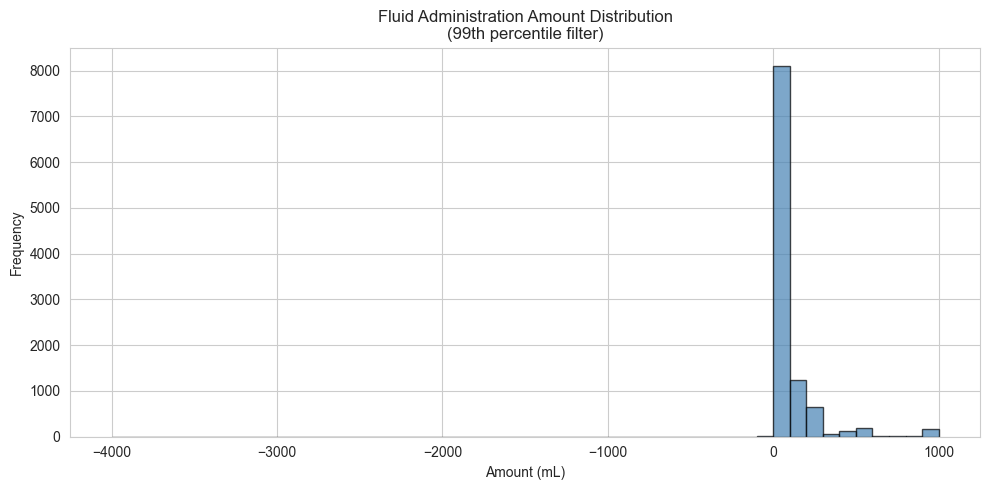

In [12]:
# Analyze fluid amounts
fluids_with_amount = fluids[fluids['amount'].notna()].copy()

if len(fluids_with_amount) > 0:
    print(f"\nFluid amount statistics:")
    print(fluids_with_amount['amount'].describe())
    
    # Plot amount distribution
    plt.figure(figsize=(10, 5))
    amounts = fluids_with_amount['amount']
    filtered_amounts = amounts[amounts <= amounts.quantile(0.99)]
    plt.hist(filtered_amounts, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    plt.xlabel('Amount (mL)')
    plt.ylabel('Frequency')
    plt.title('Fluid Administration Amount Distribution\n(99th percentile filter)')
    plt.tight_layout()
    plt.show()

## 7. Treatment Patterns per ICU Stay

In [13]:
# Count different drug categories per ICU stay
treatments_per_stay = all_inputs.groupby('icustay_id')['drug_category'].value_counts().unstack(fill_value=0)

print("\nTreatment categories per ICU stay:")
print(treatments_per_stay.describe())

# Percentage of ICU stays receiving each treatment category
treatment_coverage = (treatments_per_stay > 0).sum() / len(icustays) * 100
treatment_coverage = treatment_coverage.sort_values(ascending=False)

print("\n% of ICU stays receiving each treatment:")
print(treatment_coverage)


Treatment categories per ICU stay:
drug_category  Antibiotic  Anticoagulant  Blood Product    Diuretic  \
count          132.000000     132.000000     132.000000  132.000000   
mean             4.098485       8.795455       2.371212    5.742424   
std             12.376942      28.098175      11.154300   30.629682   
min              0.000000       0.000000       0.000000    0.000000   
25%              0.000000       0.000000       0.000000    0.000000   
50%              0.000000       0.000000       0.000000    0.000000   
75%              1.000000       5.000000       1.000000    0.000000   
max             82.000000     233.000000     120.000000  310.000000   

drug_category        Fluid      Insulin        Other     Sedative  Vasopressor  
count           132.000000   132.000000   132.000000   132.000000   132.000000  
mean             81.098485    22.363636   171.000000    46.939394    21.401515  
std             176.110169   128.680993   390.484119   153.342642    68.618300  


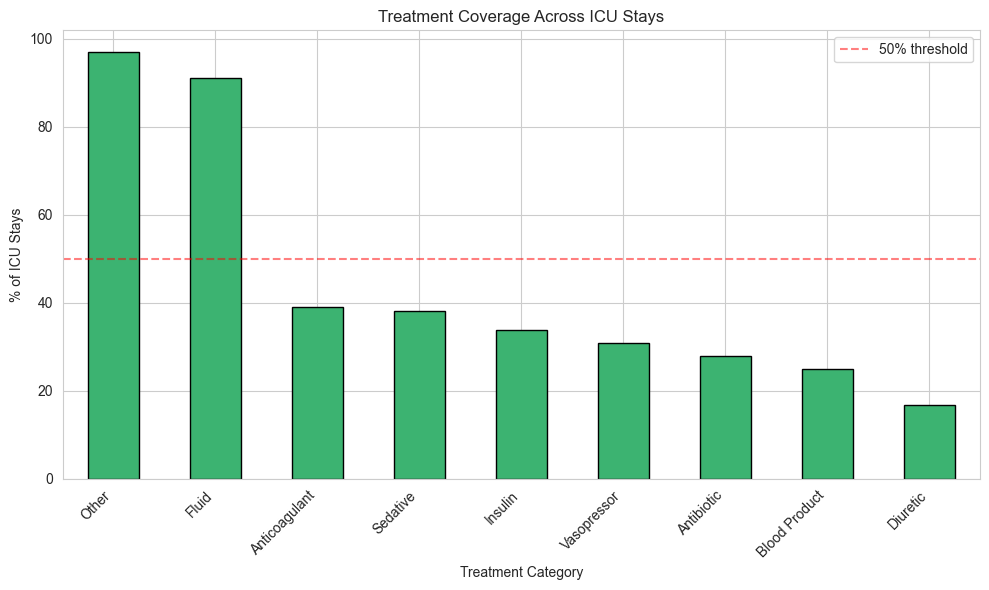

In [14]:
# Visualize treatment coverage
plt.figure(figsize=(10, 6))
treatment_coverage.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.xlabel('Treatment Category')
plt.ylabel('% of ICU Stays')
plt.title('Treatment Coverage Across ICU Stays')
plt.xticks(rotation=45, ha='right')
plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Prescriptions Analysis

In [15]:
# Most common prescriptions
prescription_counts = prescriptions['drug'].value_counts()

print("Top 20 Most Prescribed Drugs:")
print(prescription_counts.head(20))

Top 20 Most Prescribed Drugs:
drug
Potassium Chloride             529
D5W                            439
0.9% Sodium Chloride           409
NS                             362
Furosemide                     346
Insulin                        300
Iso-Osmotic Dextrose           265
5% Dextrose                    256
SW                             244
Magnesium Sulfate              206
Morphine Sulfate               206
Sodium Chloride 0.9%  Flush    206
Acetaminophen                  156
Heparin                        145
Calcium Gluconate              144
Metoprolol Tartrate            138
Vancomycin                     111
Lorazepam                      107
Bisacodyl                      105
Metoprolol                     101
Name: count, dtype: int64


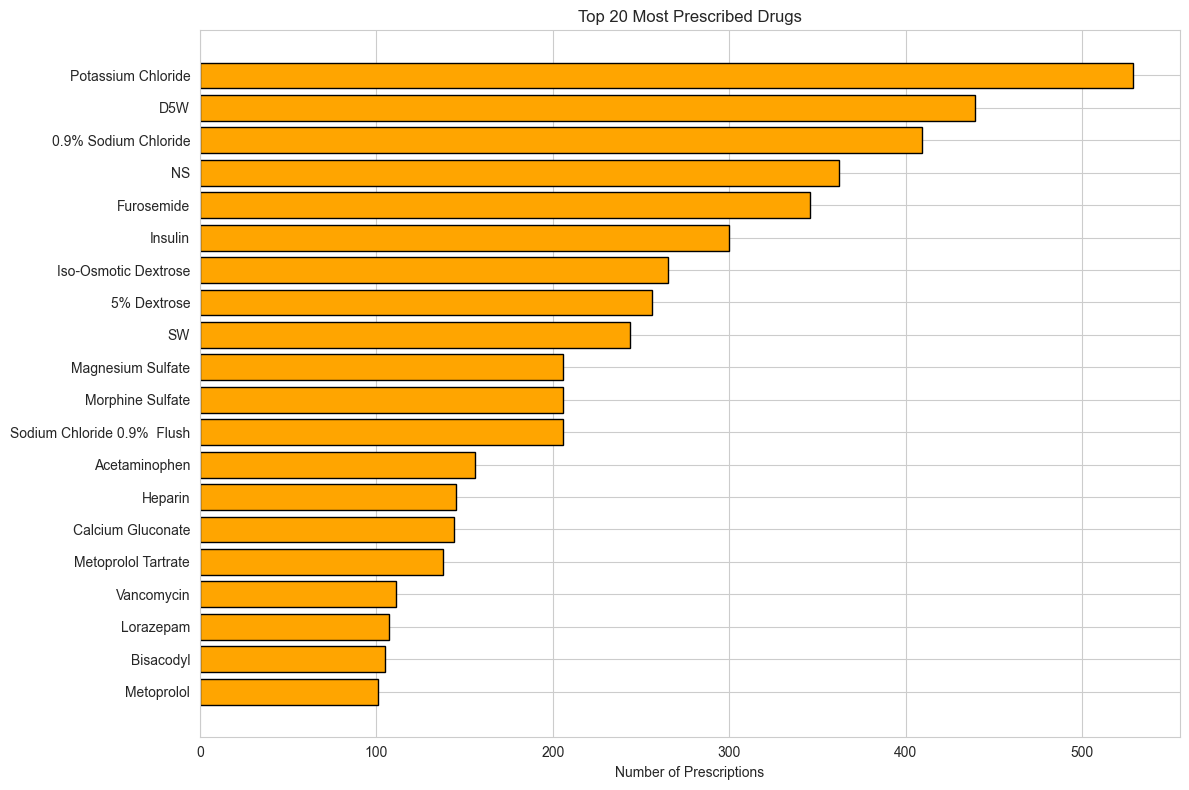

In [16]:
# Visualize
top_prescriptions = prescription_counts.head(20)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_prescriptions)), top_prescriptions.values, color='orange', edgecolor='black')
plt.yticks(range(len(top_prescriptions)), [drug[:40] for drug in top_prescriptions.index])
plt.xlabel('Number of Prescriptions')
plt.title('Top 20 Most Prescribed Drugs')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Action Space Design Recommendations

In [17]:
print("="*80)
print("ACTION SPACE DESIGN RECOMMENDATIONS")
print("="*80)

# Key treatment categories for RL
key_categories = ['Vasopressor', 'Fluid', 'Sedative', 'Antibiotic']

for category in key_categories:
    cat_data = all_inputs[all_inputs['drug_category'] == category]
    if len(cat_data) > 0:
        print(f"\n{category}:")
        print(f"  Total events: {len(cat_data):,}")
        print(f"  ICU stays: {cat_data['icustay_id'].nunique()}")
        print(f"  Coverage: {cat_data['icustay_id'].nunique() / len(icustays) * 100:.1f}%")
        
        # Top specific drugs in this category
        top_drugs = cat_data['label'].value_counts().head(5)
        print(f"  Top drugs:")
        for drug, count in top_drugs.items():
            print(f"    - {drug[:50]}: {count:,}")

print("\n" + "="*80)
print("PROPOSED ACTION SPACE DISCRETIZATION")
print("="*80)
print("""
Option 1: Discrete Actions (Simpler)
  - Action 0: No treatment / Continue current
  - Action 1: Increase vasopressor (low dose)
  - Action 2: Increase vasopressor (high dose)
  - Action 3: Decrease vasopressor
  - Action 4: Administer fluid bolus
  - Action 5: Adjust sedation
  
Option 2: Multi-Dimensional Discrete (More Realistic)
  - Dimension 1: Vasopressor level [0: none, 1: low, 2: medium, 3: high]
  - Dimension 2: Fluid rate [0: none, 1: maintenance, 2: bolus]
  - Dimension 3: Sedation level [0: none, 1: light, 2: moderate, 3: deep]
  - Total actions: 4 × 3 × 4 = 48 discrete actions

Option 3: Continuous Actions (Most Flexible)
  - Continuous values for vasopressor dose, fluid rate, sedation level
  - Requires TD3/SAC instead of DQN
  
Recommendation: Start with Option 1 for offline DQN, expand to Option 2 later.
""")

ACTION SPACE DESIGN RECOMMENDATIONS

Vasopressor:
  Total events: 2,825
  ICU stays: 42
  Coverage: 30.9%
  Top drugs:
    - Neosynephrine-k: 1,271
    - Dopamine: 809
    - Norepinephrine: 380
    - Vasopressin: 287
    - Phenylephrine: 74

Fluid:
  Total events: 10,705
  ICU stays: 124
  Coverage: 91.2%
  Top drugs:
    - .9% Normal Saline: 6,528
    - Dextrose 5%: 1,722
    - NaCl 0.9%: 1,609
    - Lactated Ringers: 473
    - .45% Normal Saline: 264

Sedative:
  Total events: 6,196
  ICU stays: 52
  Coverage: 38.2%
  Top drugs:
    - Propofol: 2,390
    - Fentanyl: 1,880
    - Midazolam: 1,485
    - Midazolam (Versed): 265
    - Fentanyl (Concentrate): 131

Antibiotic:
  Total events: 541
  ICU stays: 38
  Coverage: 27.9%
  Top drugs:
    - Vancomycin: 198
    - Piperacillin/Tazobactam (Zosyn): 124
    - Meropenem: 119
    - Cefepime: 66
    - Piperacillin: 29

PROPOSED ACTION SPACE DISCRETIZATION

Option 1: Discrete Actions (Simpler)
  - Action 0: No treatment / Continue current
  

## Key Insights

1. **Primary Actions**: Focus on vasopressors and fluids (most critical in ICU)
2. **Discretization**: Need to bin continuous rates/amounts into discrete levels
3. **Coverage**: Not all ICU stays receive all treatments (sparse action space)
4. **Temporal**: Treatments have duration (starttime/endtime in MV)

## Next Steps
- Implement action discretization module
- Map continuous rates to discrete bins
- Handle action timing (when to sample actions)
- Consider "no action" baseline for conservative RL